# Initial DOE — compare space-filling designs
Compares the DOE modes in `utils/doe.py` on the (x1 × level) mixed space:
- **shared** (current): 2 maximin-LHS x1 reused at every level → two bands.
- **per_level**: independent maximin-LHS per level.
- **slhd** (recommended): sliced LHD — each level an LHS *and* the union a full LHS in x1.
- **joint**: one 2-D LHS over (x1, category).

**Two parts.** Cells 1–10 build intuition on 1-D `branin_hetero`. The **full-suite** section at the
bottom then generalizes every mode to `d` continuous dims (`make_doe_nd`) and scores all **10 problems
(1-D → 9-D)** — because the DOE choice interacts with dimensionality and must be made against the whole
benchmark, not just Branin. Set `POOL_SEEDS` to see one seed's structure vs the distribution over seeds. **Kernel: ml_gp_env.**

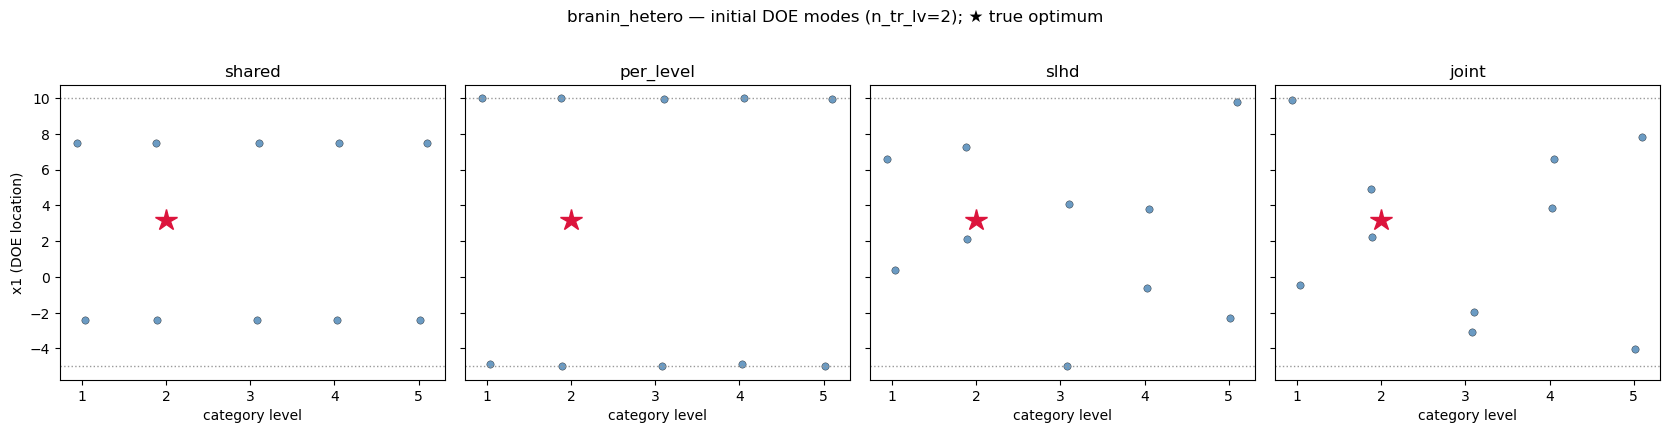

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from utils import problems as P
from utils.doe import make_doe, MODES

FUNC = 'branin_hetero'; N_TR_LV = 2; POOL_SEEDS = 1   # try 30 to see the seed distribution
spec = P.get(FUNC); gt_lv, gt_x1 = P.true_opt_location(spec)
fig, axes = plt.subplots(1, len(MODES), figsize=(4.2*len(MODES), 4.2), sharex=True, sharey=True)
for ax, mode in zip(axes, MODES):
    xs, ls = [], []
    for s in range(POOL_SEEDS):
        d = make_doe(mode, np.random.default_rng(s), spec.lb, spec.ub, spec.n_levels, N_TR_LV)
        for lv, xv in d.items():
            xs += list(xv); ls += [lv]*len(xv)
    jit = np.random.default_rng(0).uniform(-0.12, 0.12, len(ls))
    ax.scatter(np.array(ls)+jit, xs, s=28 if POOL_SEEDS==1 else 10,
               alpha=0.8 if POOL_SEEDS==1 else 0.3, c='steelblue', edgecolor='k', linewidth=0.3)
    ax.plot(gt_lv, gt_x1, marker='*', ms=16, c='crimson', zorder=5)
    ax.axhline(spec.lb, color='0.6', ls=':', lw=1); ax.axhline(spec.ub, color='0.6', ls=':', lw=1)
    ax.set_title(mode + ('' if POOL_SEEDS==1 else f'  ({POOL_SEEDS} seeds)'))
    ax.set_xlabel('category level'); ax.set_xticks(range(1, spec.n_levels+1))
axes[0].set_ylabel('x1 (DOE location)')
fig.suptitle(f'{FUNC} — initial DOE modes (n_tr_lv={N_TR_LV}); ★ true optimum', y=1.02)
fig.tight_layout()

### x1 coverage per mode
How well each mode fills the x1 range within each level (spread) and overall (marginal).

In [2]:
for mode in MODES:
    d = make_doe(mode, np.random.default_rng(0), spec.lb, spec.ub, spec.n_levels, N_TR_LV)
    allx = np.concatenate(list(d.values()))
    per_lv_distinct = len({round(float(v),3) for xv in d.values() for v in xv})
    print(f'{mode:10s}: {len(allx)} pts | distinct x1 across all levels = {per_lv_distinct} '
          f'| x1 range used [{allx.min():.2f}, {allx.max():.2f}]')

shared    : 10 pts | distinct x1 across all levels = 2 | x1 range used [-2.42, 7.49]
per_level : 10 pts | distinct x1 across all levels = 10 | x1 range used [-4.99, 10.00]
slhd      : 10 pts | distinct x1 across all levels = 10 | x1 range used [-4.98, 9.79]
joint     : 10 pts | distinct x1 across all levels = 10 | x1 range used [-4.04, 9.90]


## What each mode guarantees

| mode | pooled x1 (union) | per-level x1 | in short |
|---|---|---|---|
| **shared** | ✗ repeated (2 bands) | ✗ same at every level | current; under-explores x1 |
| **per_level** | ✗ levels overlap | ~ maximin (pins to edges) | independent per level, uncoordinated |
| **joint** | ✓ full LHS | ✗ a level can cluster | LHS treats category as a dimension |
| **slhd** | ✓ full LHS | ✓ each level is an LHS | sliced design — spread *within* and *across* levels |

**SLHD ⊃ joint's guarantee:** joint only makes the *pooled* x1 space-filling; SLHD additionally makes *each level* space-filling (one point per coarse x1 interval). See the metrics below.

## The four metrics — one consolidated set (used for 1-D *and* the full suite)

All computed by `utils.doe.doe_metrics_nd` (`bounds=[(lb,ub)]` for 1-D), all normalized so **higher = better**. Two **primary** metrics decide the verdict; two **secondary** distance metrics are kept for honesty.

### PRIMARY — these decide it

**1 · pooled uniformity  — *discrepancy: "is x spread efficiently across the whole design?"***
Pool ALL values (every level), per dim sort them and take the **smallest consecutive gap × N**, averaged over dims. Perfect LHS spacing → ≈ 1; any repeated/clustered value collapses a gap → 0. Catches `shared`'s redundancy (same x reused per level → 0) and `per_level`'s uncoordinated union (≈ 0).

**2 · per-level coverage %  — *"does EACH category span x?"***
Split each dim into `n_tr_lv` bins; a level *covers* if its points hit **all** bins in **every** dim. The % is the share of (level × dim) that do. `slhd` = 100% by construction; `joint` drops (~58%) because random (x, level) assignment leaves gaps.

### SECONDARY — distance criteria, kept for honesty (they *favor* `per_level`)

**3 · maximin  — *max–min distance: "are any two points crowded?"***
Min pairwise **Euclidean** distance among the continuous points (level ignored). `per_level` explicitly optimizes this, so it leads here — even while losing #1/#2. SLHD trades a little maximin for stratification.

**4 · gower maximin  — *mixed-space min distance***
Min pairwise **Gower** distance `= (Σⱼ|Δxⱼ|_norm + 1{different level}) / (d+1)` — continuous L1 plus a **Hamming** term for the *nominal* level (level 3 is not "between" 2 and 4, so we never put the level *number* in a distance). Because any cross-level pair gets the +1 boost, the minimum is almost always a **same-level** pair → gower rewards **within-level separation** and is **blind to cross-level coordination**. That's why a single mixed distance can't rank the modes on its own (it, too, favors `per_level`) — the reason we *decompose* into #1 (pooled/cross-category) + #2 (per-level/within-category) instead.

**Verdict rule:** the best DOE is high on **both** #1 and #2. Only **SLHD** is — at every dimensionality. #3/#4 show what it "gives up" (raw distance), which doesn't matter for surrogates that pool x across categories.

branin_hetero: consolidated metrics (n_tr_lv=2, 300 seeds; higher = better)
  PRIMARY: pooled_uniformity, per_level_cov   |   SECONDARY: pooled_maximin, gower_maximin


,pooled_uniformity,per_level_cov,pooled_maximin,gower_maximin
shared,0.000,100.000,0.000,0.331
per_level,0.002,100.000,0.000,0.494
slhd,0.366,100.000,0.037,0.116
joint,0.354,54.267,0.035,0.068



Tip: raise N_TR_LV (top cell) to 3-4 to see the SLHD vs joint gap widen.


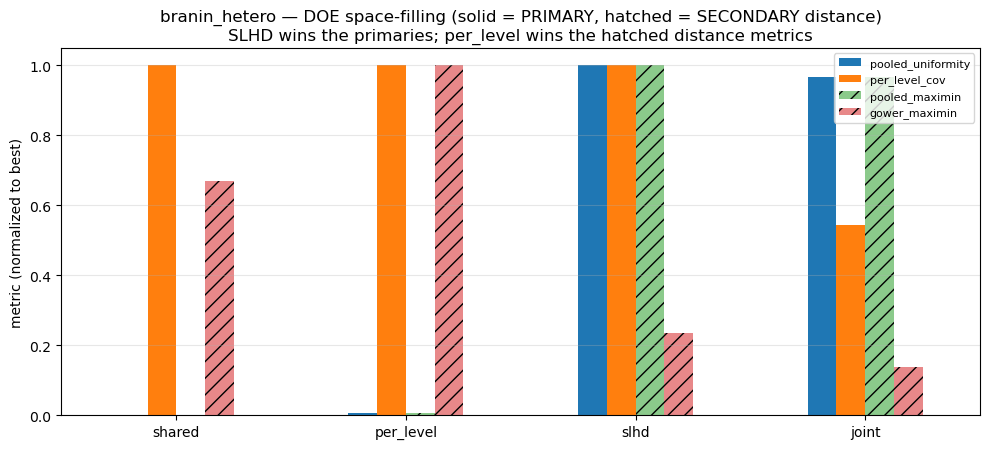

In [3]:
import pandas as pd
from utils.doe import doe_metrics_nd, METRICS
NS = 300                                          # seeds to average the metrics over
b1 = [(spec.lb, spec.ub)]                          # 1-D bounds -> same doe_metrics_nd as the suite
tbl = pd.DataFrame({m: doe_metrics_nd(m, b1, spec.n_levels, N_TR_LV, n_seeds=NS) for m in MODES}).T[METRICS]
print(f'{FUNC}: consolidated metrics (n_tr_lv={N_TR_LV}, {NS} seeds; higher = better)')
print('  PRIMARY: pooled_uniformity, per_level_cov   |   SECONDARY: pooled_maximin, gower_maximin')
display(tbl.round(3))

# normalized bar of all four (primaries filled, secondaries hatched to flag "SLHD trades these")
norm = tbl / tbl.max()
fig, ax = plt.subplots(figsize=(10, 4.6))
norm.plot(kind='bar', ax=ax, rot=0)
for k, bars in enumerate(ax.containers):                # hatch the two secondary (distance) metrics
    if METRICS[k] in ('pooled_maximin', 'gower_maximin'):
        for bar in bars: bar.set_hatch('//'); bar.set_alpha(0.55)
ax.set_ylabel('metric (normalized to best)')
ax.set_title(f'{FUNC} — DOE space-filling (solid = PRIMARY, hatched = SECONDARY distance)\n'
             'SLHD wins the primaries; per_level wins the hatched distance metrics')
ax.legend(loc='upper right', fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
print('\nTip: raise N_TR_LV (top cell) to 3-4 to see the SLHD vs joint gap widen.')

## How the categorical level enters each metric

The category is **nominal** — level 3 is not "between" 2 and 4 — so we never put the level *number* into a distance (that would invent a false ordering). Each metric uses the level **structurally**:

| metric | role of the level | view |
|---|---|---|
| 1 · pooled uniformity | **pool across** levels — gather every level's x into one set, measure spacing | cross-category (union) |
| 2 · per-level coverage % | **group by** level — bin coverage *within each* level, then average | within-category |
| 3 · maximin | levels **ignored** — pure continuous Euclidean min distance | continuous only |
| 4 · gower maximin | level enters as a **Hamming** term (+1 if different), continuous as L1 | mixed (nominal) |

So #1 is the **cross-category** (union) view, #2 the **within-category** view; #3 drops the category entirely, and #4 is the "correct" *joint nominal* distance. Together #1 + #2 capture the *sliced* structure (spread within AND across levels).

### Why the joint mixed distance (#4, gower) can't rank the modes alone
Gower is **dominated by the categorical term** — any two points at *different* levels are ≥ `1/(d+1)` apart, so the minimum pairwise distance almost always comes from a *same-level* pair and collapses to *"the closest two x within any level."* It rewards within-level separation and is **blind to cross-level coordination** — so it ranks `per_level` best even though `per_level` has ~0 pooled uniformity (overlapping x across levels). That mismatch is exactly why we lead with the pooled + per-level **decomposition** and keep gower (and plain maximin) only as secondary honesty checks. The cell below shows gower per mode:

In [4]:
# Metric #4 (gower) alongside #3 (maximin), from the SAME doe_metrics_nd used everywhere.
gtab = pd.DataFrame({m: doe_metrics_nd(m, b1, spec.n_levels, N_TR_LV, n_seeds=NS) for m in MODES}).T
gtab = gtab[['pooled_maximin', 'gower_maximin']].rename(
    columns={'pooled_maximin': 'maximin (#3)', 'gower_maximin': 'gower (#4)'})
print('secondary distance metrics — both rank per_level best (max within-level separation):')
display(gtab.round(3))
print('^ per_level wins BOTH distance metrics yet has ~0 pooled uniformity (overlapping x across levels).\n'
      '  That is why the verdict rests on the PRIMARY pair (#1 pooled uniformity + #2 per-level coverage).')

secondary distance metrics — both rank per_level best (max within-level separation):


,maximin (#3),gower (#4)
shared,0.000,0.331
per_level,0.000,0.494
slhd,0.037,0.116
joint,0.035,0.068


^ per_level wins BOTH distance metrics yet has ~0 pooled uniformity (overlapping x across levels).
  That is why the verdict rests on the PRIMARY pair (#1 pooled uniformity + #2 per-level coverage).


### Illustration of metric #1 (pooled x1 uniformity)
Pool every level's x1 and lay them on a line. `shared` piles onto a few values (gaps collapse → uniformity 0); `slhd` tiles the range (even gaps → uniformity high). This is what metric #1 measures.

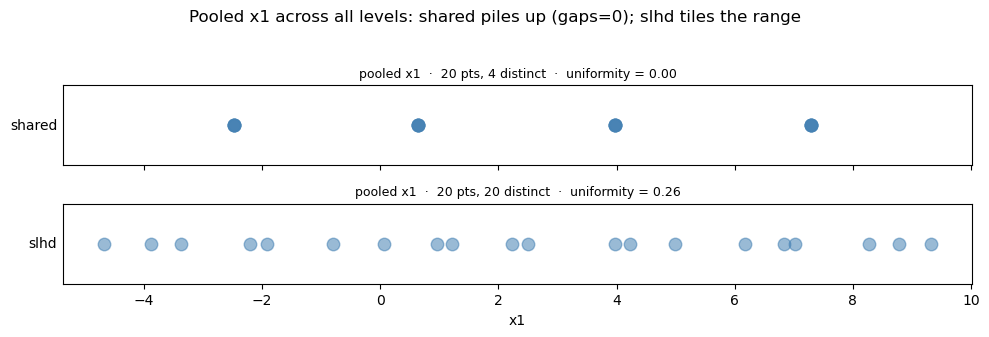

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3.2), sharex=True)
for ax, mode in zip(axes, ['shared', 'slhd']):
    d = make_doe(mode, np.random.default_rng(3), spec.lb, spec.ub, spec.n_levels, 4)
    allx = np.sort(np.concatenate(list(d.values())))
    g = np.min(np.diff((allx-spec.lb)/(spec.ub-spec.lb)))*len(allx)
    ax.plot(allx, np.zeros_like(allx), 'o', ms=9, alpha=0.55, color='steelblue')
    ax.set_yticks([]); ax.set_ylabel(f'{mode}', rotation=0, ha='right', va='center')
    ax.set_title(f'pooled x1  ·  {len(allx)} pts, {len(set(np.round(allx,3)))} distinct  ·  uniformity = {g:.2f}', fontsize=9)
axes[-1].set_xlabel('x1'); fig.suptitle('Pooled x1 across all levels: shared piles up (gaps=0); slhd tiles the range', y=1.04)
fig.tight_layout()

---
# The full test suite — does the SLHD verdict survive higher dimensions?

Everything above is 1-D Branin, for intuition. But the benchmark spans **10 problems, up to 9 continuous
dims**, and DOE quality *interacts with dimensionality* — so the decision has to be made against the whole
suite. The DOE only needs each problem's **(d continuous dims, per-dim bounds, #levels)** — not its
equation — so we can score even the not-yet-implemented multi-dim problems.

`utils.doe.make_doe_nd` generalizes every mode to `d` dims: each continuous dim gets the chosen 1-D design,
then within a level the dims are **shuffled independently** to decorrelate them (→ a proper d-dim LHS per
slice). `PROBLEM_GRID` holds the suite's structure; `doe_metrics_nd` scores it in any dimension.

In [6]:
from utils.doe import PROBLEM_GRID, make_doe_nd, doe_metrics_nd
rows = []
for nm, g in PROBLEM_GRID.items():
    rows.append(dict(problem=nm, d_cont=g.d, n_levels=g.n_levels,
                     xlsx=g.n_init_xlsx, n_init=g.n_init, per_level=g.n_tr_lv, num_iter=g.num_iter,
                     bounds=(f'{tuple(g.bounds[0])}' + (f'  … (x{g.d})' if g.d > 1 else ''))))
grid = pd.DataFrame(rows).set_index('problem')
print('Full test suite — geometry + budget (xlsx / num_iter from resources/init_doe_iter.xlsx):')
display(grid)
print('A sliced LHD requires n_levels | n_init: only then is every slice an LHS on equal-width bins.')
print('Five problems (50/4, 30/4) are not, so n_init ROUNDS UP to the next multiple (50→52, 30→32) —')
print('never spending less budget than the spreadsheet asks. Below: at 50 the per-level coverage of the')
print('10-D problems collapses to 19%; at 48 or 52 it is 100%. Hence the rounding.')

Full test suite — geometry + budget (xlsx / num_iter from resources/init_doe_iter.xlsx):


,d_cont,n_levels,xlsx,n_init,per_level,num_iter,bounds
problem,,,,,,,
branin_hetero,1,5,10,10,2,50,"(-5, 10)"
sixhump_camel,1,4,8,8,2,50,"(-2, 2)"
griewank_2d,1,4,8,8,2,50,"(-5, 5)"
ackley_2d,1,4,8,8,2,50,"(-3, 3)"
griewank_10d,9,4,50,52,13,200,"(-5, 5) … (x9)"
ackley_10d,9,4,50,52,13,200,"(-5, 5) … (x9)"
rastrigin_6d,5,4,30,32,8,200,"(-5, 5) … (x5)"
golinski,6,5,30,30,6,200,"(2.6, 3.6) … (x6)"
piston,6,4,30,32,8,200,"(30, 60) … (x6)"


A sliced LHD requires n_levels | n_init: only then is every slice an LHS on equal-width bins.
Five problems (50/4, 30/4) are not, so n_init ROUNDS UP to the next multiple (50→52, 30→32) —
never spending less budget than the spreadsheet asks. Below: at 50 the per-level coverage of the
10-D problems collapses to 19%; at 48 or 52 it is 100%. Hence the rounding.


### Space-filling across every problem — the decisive table

The **same four metrics** (`doe_metrics_nd`) as the 1-D section, now on every problem — *higher = better*:
- **PRIMARY · pooled_uniformity** — the union is stratified (LHS) in **every** dim. SLHD's core guarantee. `shared` = 0 (duplicates); `per_level` ≈ 0 (uncoordinated union).
- **PRIMARY · per_level_cov %** — every level covers every bin in every dim. SLHD = 100% by construction; `joint` drops (~58%).
- **SECONDARY · maximin / gower** — distance criteria. `per_level` *optimizes* distance so it leads both — even while losing the primaries. Kept only for honesty (they ignore, resp. are dominated by, the categorical structure the shared surrogates rely on).

The two pivots below show the primaries per problem; the averaged bar + combined score that follow fold in all four.

In [7]:
NS_ND = 120   # seeds to average the d-dim metrics over
recs = []
for nm, g in PROBLEM_GRID.items():
    for mode in MODES:
        m = doe_metrics_nd(mode, g.bounds, g.n_levels, n_init=g.n_init, n_seeds=NS_ND)
        recs.append(dict(problem=nm, d=g.d, mode=mode, **m))
suite = pd.DataFrame(recs)

def piv(metric):
    return suite.pivot(index='problem', columns='mode', values=metric)[MODES].loc[list(PROBLEM_GRID)]

print(f'[{NS_ND} seeds, each problem at its OWN (rounded) n_init]')
print('PRIMARY 1 · pooled_uniformity  (SLHD & joint high; shared=0, per_level≈0)')
display(piv('pooled_uniformity').round(3))
print('PRIMARY 2 · per_level_cov %  (SLHD=100 everywhere now that n_levels | n_init; joint drops)')
display(piv('per_level_cov').round(0))
print('SECONDARY · maximin  and  gower  (per_level leads BOTH — distance criteria, honesty only)')
sec = pd.concat({'maximin': piv('pooled_maximin'), 'gower': piv('gower_maximin')}, axis=1)
display(sec.round(3))

[120 seeds, each problem at its OWN (rounded) n_init]
PRIMARY 1 · pooled_uniformity  (SLHD & joint high; shared=0, per_level≈0)


mode,shared,per_level,slhd,joint
problem,,,,
branin_hetero,0.0,0.002,0.364,0.337
sixhump_camel,0.0,0.002,0.373,0.390
griewank_2d,0.0,0.002,0.373,0.390
ackley_2d,0.0,0.002,0.373,0.390
griewank_10d,0.0,0.021,0.169,0.170
ackley_10d,0.0,0.021,0.169,0.170
rastrigin_6d,0.0,0.021,0.221,0.216
golinski,0.0,0.014,0.222,0.222
piston,0.0,0.021,0.221,0.215


PRIMARY 2 · per_level_cov %  (SLHD=100 everywhere now that n_levels | n_init; joint drops)


mode,shared,per_level,slhd,joint
problem,,,,
branin_hetero,100.0,100.0,100.0,52.0
sixhump_camel,100.0,100.0,100.0,57.0
griewank_2d,100.0,100.0,100.0,57.0
ackley_2d,100.0,100.0,100.0,57.0
griewank_10d,0.0,100.0,100.0,0.0
ackley_10d,0.0,100.0,100.0,0.0
rastrigin_6d,0.0,100.0,100.0,1.0
golinski,0.0,100.0,100.0,3.0
piston,0.0,100.0,100.0,1.0


SECONDARY · maximin  and  gower  (per_level leads BOTH — distance criteria, honesty only)


maximin                          gower                        
mode           shared per_level   slhd  joint shared per_level   slhd  joint
problem                                                                     
branin_hetero   0.000     0.000  0.036  0.034  0.331     0.494  0.112  0.067
sixhump_camel   0.000     0.000  0.047  0.049  0.331     0.494  0.126  0.088
griewank_2d     0.000     0.000  0.047  0.049  0.331     0.494  0.126  0.088
ackley_2d       0.000     0.000  0.047  0.049  0.331     0.494  0.126  0.088
griewank_10d    0.297     0.445  0.429  0.422  0.101     0.155  0.149  0.126
ackley_10d      0.297     0.445  0.429  0.422  0.101     0.155  0.149  0.126
rastrigin_6d    0.151     0.231  0.222  0.230  0.098     0.150  0.132  0.098
golinski        0.218     0.322  0.301  0.305  0.138     0.200  0.168  0.120
piston          0.205     0.310  0.287  0.302  0.111     0.166  0.143  0.114
otl_circuit     0.151     0.231  0.222  0.230  0.098     0.150  0.132  0.098

In [8]:
# Why n_init must be divisible by n_levels: sweep n_init for a 10-D, 4-level problem.
b10 = [(-5, 5)] * 9
rows = []
for n in (48, 49, 50, 51, 52, 56):
    s = doe_metrics_nd('slhd', b10, 4, n_init=n, n_seeds=60)
    p = doe_metrics_nd('per_level', b10, 4, n_init=n, n_seeds=60)
    rows.append(dict(n_init=n, per_level_pts=n/4, divisible=(n % 4 == 0),
                     slhd_cov=s['per_level_cov'], per_level_cov=p['per_level_cov'],
                     slhd_unif=s['pooled_uniformity']))
display(pd.DataFrame(rows).set_index('n_init').round(3))
print('Only at a multiple of n_levels is each slice an LHS on equal bins -> 100% coverage.')
print('Off a multiple, r levels carry an extra point and SLHD loses the very guarantee we picked it for')
print('(the union stays a full LHS regardless). This is why the suite rounds 50→52 and 30→32.')

,per_level_pts,divisible,slhd_cov,per_level_cov,slhd_unif
n_init,,,,,
48,12.00,True,100.000,100.000,0.183
49,12.25,False,39.444,86.065,0.175
50,12.50,False,18.935,72.917,0.181
51,12.75,False,10.556,56.343,0.174
52,13.00,True,100.000,100.000,0.170
56,14.00,True,100.000,100.000,0.165


Only at a multiple of n_levels is each slice an LHS on equal bins -> 100% coverage.
Off a multiple, r levels carry an extra point and SLHD loses the very guarantee we picked it for
(the union stays a full LHS regardless). This is why the suite rounds 50→52 and 30→32.


combined PRIMARY score (pooled_unif_norm × coverage_frac), averaged over the suite — higher is better:
mode
slhd         0.998
joint        0.230
per_level    0.047
shared       0.000


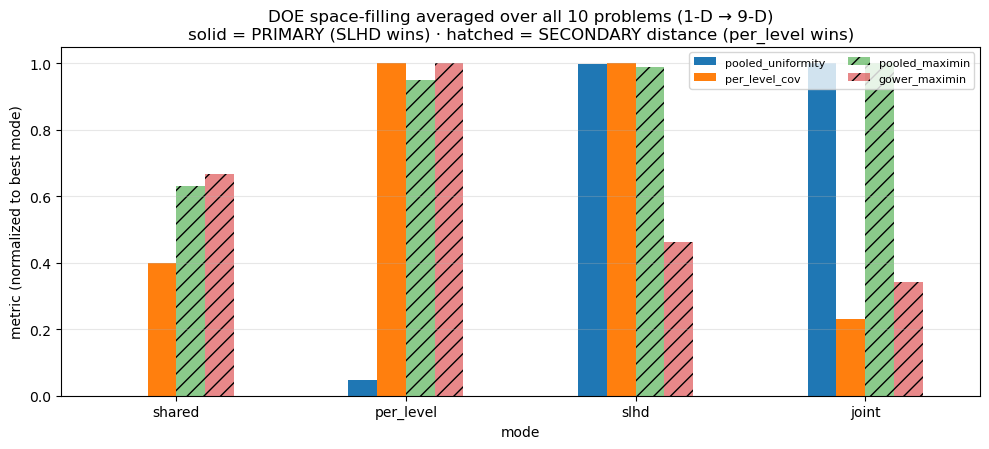

In [9]:
# Averaged over ALL 10 problems: only SLHD is high on BOTH primaries; per_level owns the (hatched) distance metrics.
avg = suite.groupby('mode')[METRICS].mean().loc[MODES]
avgn = avg / avg.max()                                     # normalize each metric to its best mode
fig, ax = plt.subplots(figsize=(10, 4.6))
avgn.plot(kind='bar', ax=ax, rot=0)
for k, bars in enumerate(ax.containers):                   # hatch the two secondary (distance) metrics
    if METRICS[k] in ('pooled_maximin', 'gower_maximin'):
        for bar in bars: bar.set_hatch('//'); bar.set_alpha(0.55)
ax.set_ylabel('metric (normalized to best mode)')
ax.set_title('DOE space-filling averaged over all 10 problems (1-D → 9-D)\n'
             'solid = PRIMARY (SLHD wins) · hatched = SECONDARY distance (per_level wins)')
ax.legend(loc='upper right', ncol=2, fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
# combined score = uniformity (norm) x coverage fraction  -> rewards being good at BOTH primaries
combo = (avg['pooled_uniformity'] / avg['pooled_uniformity'].max()) * (avg['per_level_cov'] / 100)
print('combined PRIMARY score (pooled_unif_norm × coverage_frac), averaged over the suite — higher is better:')
print(combo.sort_values(ascending=False).round(3).to_string())

### Seeing it in a multi-dim problem
Pick any problem in `VIZ_FUNC`. For `d > 1` we can't scatter the whole space, so we project onto two
continuous dims `(x_i, x_j)` and colour by level. Watch: `shared` repeats the *same* cloud at every level,
`per_level`/`joint` spread but leave gaps, `slhd` tiles each dim and keeps every level represented.

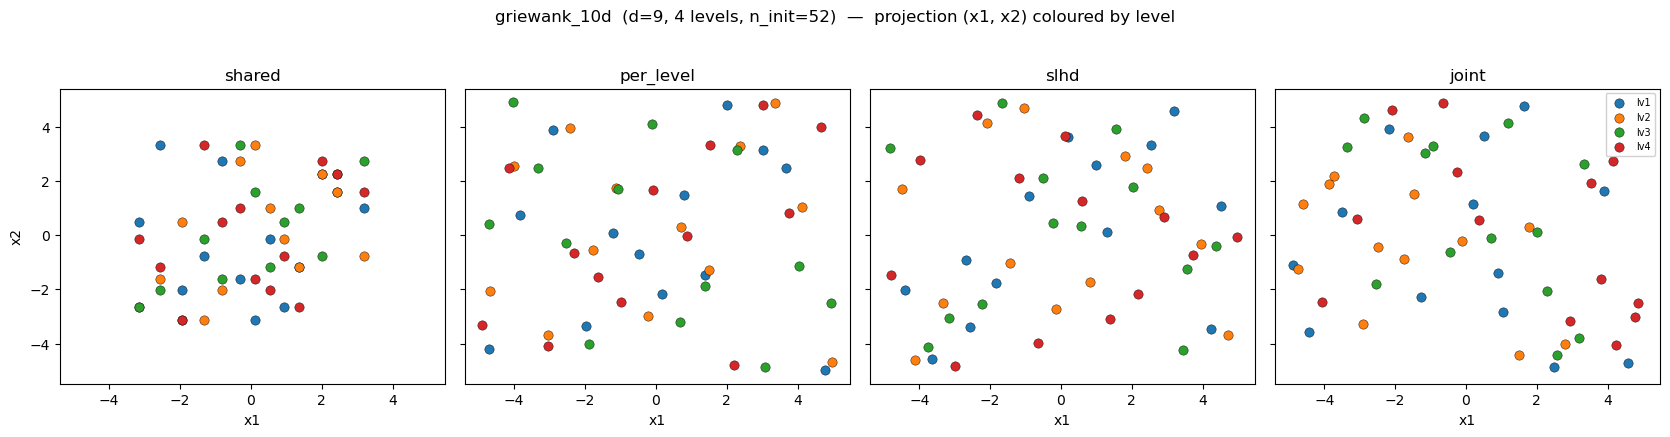

In [10]:
VIZ_FUNC = 'griewank_10d'          # any key of PROBLEM_GRID; try 'golinski', 'branin_hetero', ...
g = PROBLEM_GRID[VIZ_FUNC]
bV, dV, nlvV = np.array(g.bounds, float), g.d, g.n_levels
i, j = (0, 1) if dV > 1 else (0, 0)
cmap = plt.cm.tab10
fig, axes = plt.subplots(1, len(MODES), figsize=(4.2*len(MODES), 4.2), sharex=True, sharey=True)
for ax, mode in zip(axes, MODES):
    try:
        dd = make_doe_nd(mode, np.random.default_rng(0), bV, nlvV, n_init=g.n_init)
    except ValueError as e:                      # `shared` needs n_init divisible by n_levels
        ax.text(0.5, 0.5, f'{mode}\nnot expressible\nat n_init={g.n_init}', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='crimson')
        ax.set_title(mode); continue
    for lv, pts in dd.items():
        c = cmap((lv-1) % 10)
        if dV > 1:
            ax.scatter(pts[:, i], pts[:, j], s=45, color=c, edgecolor='k', linewidth=0.3, label=f'lv{lv}')
        else:
            jit = np.random.default_rng(lv).uniform(-0.12, 0.12, len(pts))
            ax.scatter(np.full(len(pts), lv)+jit, pts[:, 0], s=45, color=c, edgecolor='k', linewidth=0.3)
    ax.set_title(mode)
    ax.set_xlabel(f'x{i+1}' if dV > 1 else 'category level')
    if dV == 1: ax.set_xticks(range(1, nlvV+1))
axes[0].set_ylabel(f'x{j+1}' if dV > 1 else 'x1')
sub = f'projection (x{i+1}, x{j+1}) coloured by level' if dV > 1 else 'per level'
fig.suptitle(f'{VIZ_FUNC}  (d={dV}, {nlvV} levels, n_init={g.n_init})  —  {sub}', y=1.03)
if dV > 1: axes[-1].legend(fontsize=7, loc='upper right', framealpha=0.9)
fig.tight_layout()

## Verdict across the whole suite

|  | PRIMARY pooled_unif | PRIMARY per_level_cov | *sec.* maximin | *sec.* gower | across 1-D → 9-D |
|---|---|---|---|---|---|
| shared | ✗ 0 | ✓ 100% | mid | mid | redundant (same cloud per level) in every d |
| per_level | ✗ ≈0 | ✓ 100% | ✓ **best** | ✓ **best** | union uncoordinated / overlapping |
| joint | ✓ | ✗ ~58% | mid | low | coverage gaps per level |
| **slhd** | ✓ | ✓ **100%** | mid | low | **only mode good on both primaries, at every d** |

- **SLHD is the choice.** It is the only mode high on *both* primary metrics — pooled uniformity and per-level coverage — and that holds from 1-D Branin to the 9-D Griewank/Ackley problems. The combined primary score ranks it first at every dimensionality.
- What SLHD "loses" is the two **secondary distance** metrics (maximin, gower), which `per_level` explicitly optimizes. But `per_level` pays with a non-stratified union — bad for the **shared** surrogates (LVGP, categorical-kernel) that pool x across categories. gower in particular is dominated by the categorical term, so it just rewards within-level separation. For our model mix, coordinated coverage beats raw distance.
- **Domain: full `[lb, ub]` (no 1/6 inset).** The inset only existed to keep `shared`'s two bands off the edges; SLHD already stratifies across the whole range.

**✅ Decision (confirmed): `slhd`, full domain — WIRED into the sweep, and SHARED across methods.** The design is generated **once in Python** per (function, seed, n_rep) by `utils/doe_cache.py` (SLHD via `problems.initial_doe`, default `mode="slhd"`) and written to a `.mat`. **All four models load that same file** — the two python surrogates directly, and both MATLAB drivers via the `doe_file` argument — so for a given seed every method starts from the **byte-identical** initial dataset (common random numbers). The section below shows that shared design.

---
## The shared initial design we'll actually run — the 4 one-D problems (SLHD + replicates)

The **exact shared dataset** loaded from `utils/doe_cache.py` (`doe_cache.load(fn, seed, n_rep)`) — the
identical bytes every one of the four models starts from at iteration 0 (common random numbers):
- **lines** = the true `f(x1 | level)`, one per categorical level;
- **big dots** = the SLHD samples (each level its own `n_tr_lv` x1 locations, over the full domain);
- **small dots** = the `N_REP` **noisy replicates** at each sample — their vertical spread *is* the heteroscedastic σ(x1 | level) (note how it grows with |x1| and differs per level);
- **★** = the true optimum.

Every design point (and every later BO pick) is evaluated `N_REP` times, giving each point a mean **and**
a sample variance — the signal the noise-aware models use. Because this design is generated once and
shared, any later difference between methods is model/acquisition, not the initial sampling.

branin_hetero: per-level SLHD x1  lv1=[+0.41, +6.59]  lv2=[+2.09, +7.26]  lv3=[-4.98, +4.05]  lv4=[-0.63, +3.79]  lv5=[-2.28, +9.79]
sixhump_camel: per-level SLHD x1  lv1=[-1.49, +0.27]  lv2=[-0.59, +1.41]  lv3=[-1.98, +0.97]  lv4=[-0.04, +1.50]
griewank_2d: per-level SLHD x1  lv1=[-3.73, +0.68]  lv2=[-1.48, +3.52]  lv3=[-4.95, +2.42]  lv4=[-0.11, +3.75]
ackley_2d: per-level SLHD x1  lv1=[-2.24, +0.41]  lv2=[-0.89, +2.11]  lv3=[-2.97, +1.45]  lv4=[-0.07, +2.25]


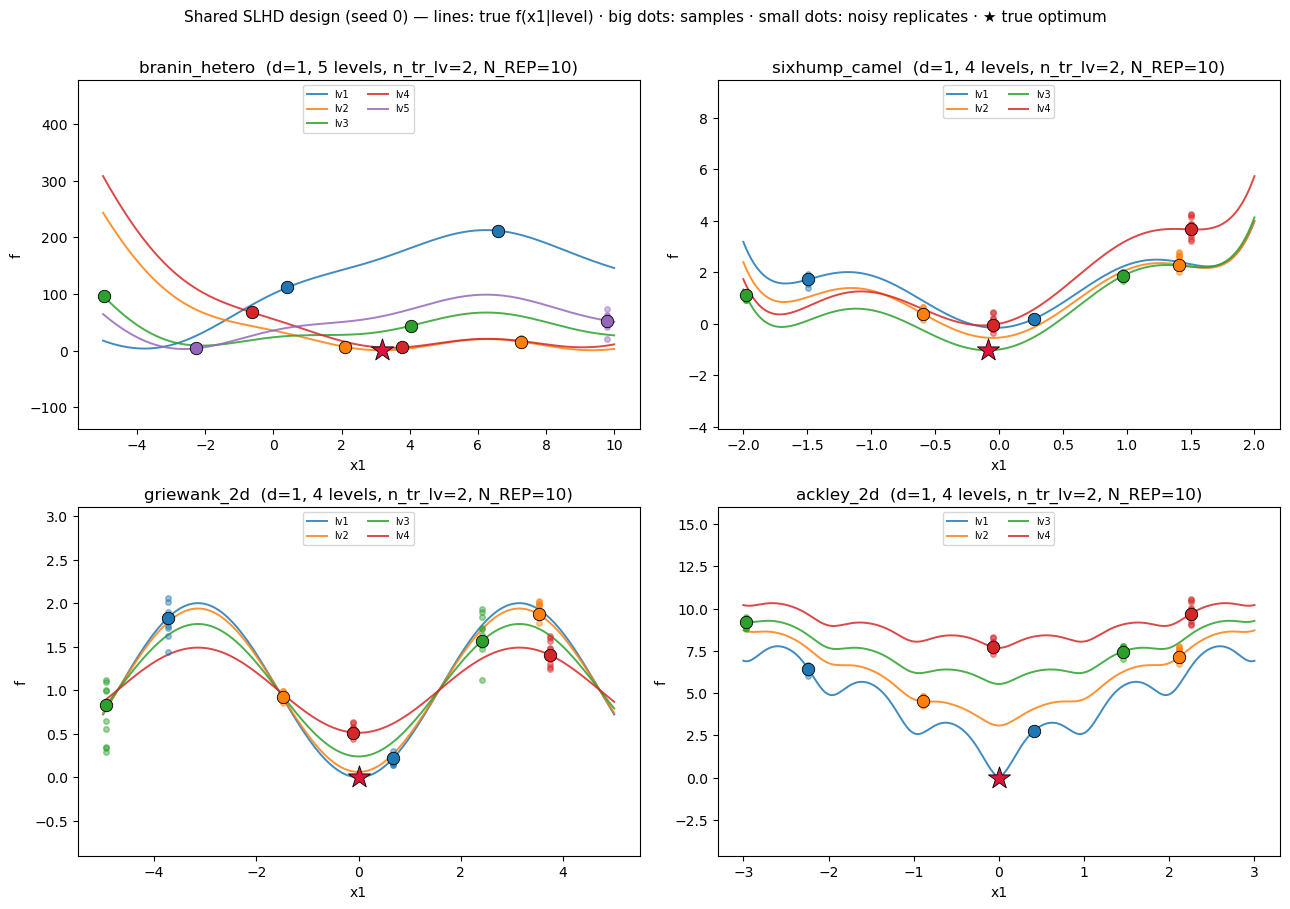

In [11]:
from utils import doe_cache
N_REP = 10                                 # replicates per design point (sweep uses N_REP_LIST=[3, 10])
DOE_SEED = 0
funcs4 = ['branin_hetero', 'sixhump_camel', 'griewank_2d', 'ackley_2d']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, nm in zip(axes.ravel(), funcs4):
    sp = P.get(nm)
    xx = np.linspace(sp.lb, sp.ub, 400)
    fcurves = [sp.f_true_level(xx, lv) for lv in sp.levels]
    for lv, fc in zip(sp.levels, fcurves):
        ax.plot(xx, fc, color=plt.cm.tab10((lv-1) % 10), lw=1.4, alpha=0.85, label=f'lv{lv}', zorder=2)
    ds = doe_cache.load(nm, DOE_SEED, N_REP)                     # THE shared dataset both engines load
    X, Yrep = ds['X_sample'], ds['Y_rep']
    for r in range(len(X)):
        x1, lv = X[r]; c = plt.cm.tab10((int(lv)-1) % 10)
        ft = float(sp.f_true_level(x1, int(lv)))
        ax.scatter(np.full(N_REP, x1), Yrep[r], s=16, color=c, alpha=0.45, zorder=3)   # noisy replicates
        ax.scatter([x1], [ft], s=80, color=c, edgecolor='k', linewidth=0.6, zorder=5)  # sample @ true f
    gt_lv, gt_x1 = P.true_opt_location(sp)
    ax.scatter([gt_x1], [float(sp.f_true_level(gt_x1, gt_lv))], marker='*', s=280,
               c='crimson', edgecolor='k', linewidth=0.6, zorder=6)
    fmin = min(c.min() for c in fcurves); fmax = max(c.max() for c in fcurves); span = fmax - fmin
    ax.set_ylim(fmin - 0.45*span, fmax + 0.55*span)             # keep curves readable if a replicate blows up
    ax.set_title(f'{nm}  (d=1, {sp.n_levels} levels, n_tr_lv={sp.n_tr_lv}, N_REP={N_REP})')
    ax.set_xlabel('x1'); ax.set_ylabel('f'); ax.legend(fontsize=7, ncol=2, loc='upper center')
fig.suptitle('Shared SLHD design (seed 0) — lines: true f(x1|level) · big dots: samples · small dots: noisy replicates · ★ true optimum',
             y=1.005, fontsize=11)
fig.tight_layout()

# print the design tables so the exact x1 (per level) is inspectable -- this is what MATLAB loads too
for nm in funcs4:
    sp = P.get(nm); X = doe_cache.load(nm, DOE_SEED, N_REP)['X_sample']
    print(f'{nm}: per-level SLHD x1  ' +
          '  '.join(f'lv{int(lv)}=[{", ".join(f"{v:+.2f}" for v in sorted(X[X[:,1]==lv,0]))}]' for lv in sp.levels))

---
## Compare LHS sampling methods at the function level (why SLHD looks like "two bands")

The plot above can look like the same two x1 locations repeated across levels — but it's **not** the old
`shared` design. With only **`n_tr_lv = 2` points per level**, SLHD guarantees each level spans the domain,
so it puts **one point in the left half and one in the right half** (its 2 coarse intervals) for *every*
level. That reads as two vertical bands, yet the exact x differs per level (the printed tables above show
distinct values). It's the sliced structure, not redundancy.

Two knobs change the look:
- **`N_TR_LV_VIZ`** — more points per level → each level tiles the range with more, finer points (less "banded").
- **`VIZ_MODE`** — flip between `shared` / `per_level` / `slhd` / `joint` to see how each actually samples the function.

The cell below overlays all four modes for one problem (true `f` + samples + noisy replicates), so you can
pick the one you want. Change `VIZ_PROBLEM` / `N_TR_LV_VIZ` and re-run. If you decide on a different mode or
`n_tr_lv`, tell me and I'll re-wire `problems.initial_doe` (and thus the shared DOE) accordingly.

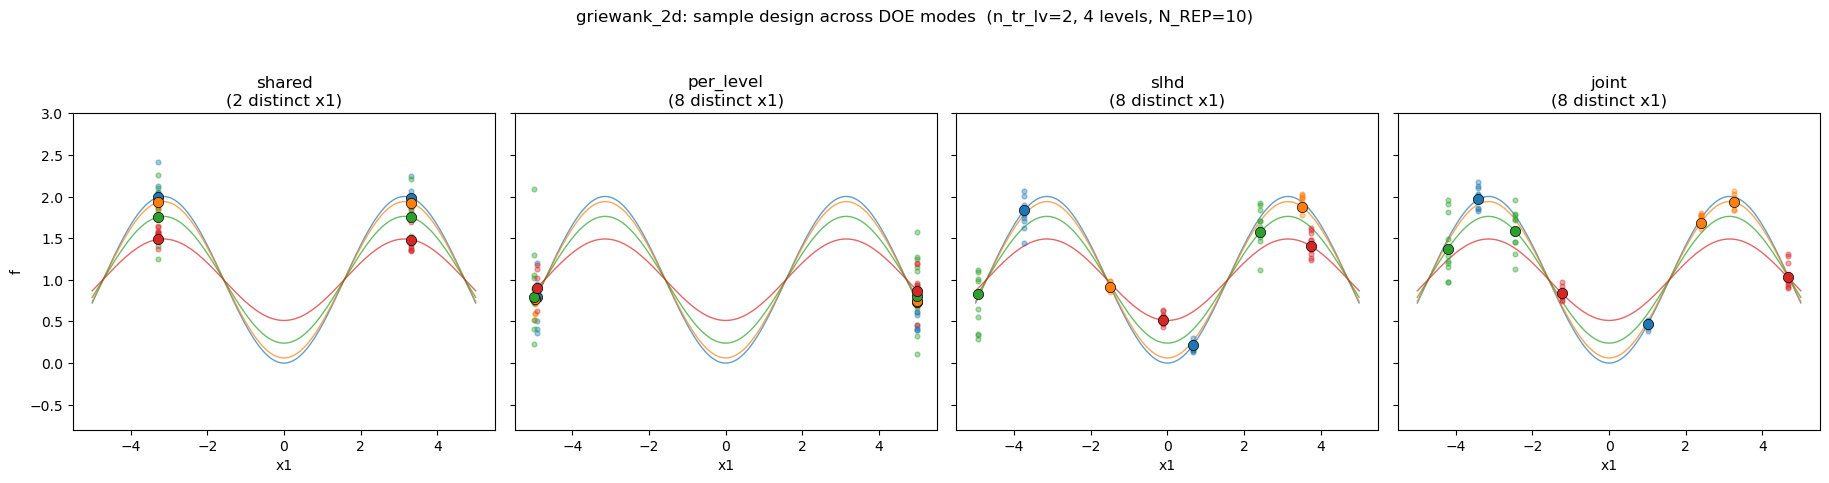

In [12]:
VIZ_PROBLEM = 'griewank_2d'    # any of the 4 one-D problems
N_TR_LV_VIZ = 2                # points PER LEVEL (raise to 3-4 to reduce the "banding")
N_REP_VIZ   = 10
SEED_VIZ    = 0
sp = P.get(VIZ_PROBLEM)
xx = np.linspace(sp.lb, sp.ub, 400)
fcurves = [sp.f_true_level(xx, lv) for lv in sp.levels]
fmin = min(c.min() for c in fcurves); fmax = max(c.max() for c in fcurves); pad = fmax - fmin

fig, axes = plt.subplots(1, len(MODES), figsize=(4.6*len(MODES), 4.6), sharey=True)
for ax, mode in zip(axes, MODES):
    for lv, fc in zip(sp.levels, fcurves):
        ax.plot(xx, fc, color=plt.cm.tab10((lv-1) % 10), lw=1.0, alpha=0.7, zorder=2)
    rng = np.random.default_rng(SEED_VIZ)
    doe = make_doe(mode, rng, sp.lb, sp.ub, sp.n_levels, N_TR_LV_VIZ)   # {level: x1 array}
    for lv, xs in doe.items():
        c = plt.cm.tab10((lv-1) % 10)
        for x in np.atleast_1d(xs):
            ft = float(sp.f_true_level(x, lv))
            yr = ft + rng.standard_normal(N_REP_VIZ) * float(sp.sigma_level(x, lv))
            ax.scatter(np.full(N_REP_VIZ, x), yr, s=12, color=c, alpha=0.4, zorder=3)   # noisy replicates
            ax.scatter([x], [ft], s=55, color=c, edgecolor='k', linewidth=0.5, zorder=5)  # sample
    ndist = len({round(float(v), 3) for xv in doe.values() for v in np.atleast_1d(xv)})
    ax.set_title(f'{mode}\n({ndist} distinct x1)'); ax.set_xlabel('x1')
    ax.set_ylim(fmin - 0.4*pad, fmax + 0.5*pad)
axes[0].set_ylabel('f')
fig.suptitle(f'{VIZ_PROBLEM}: sample design across DOE modes  '
             f'(n_tr_lv={N_TR_LV_VIZ}, {sp.n_levels} levels, N_REP={N_REP_VIZ})', y=1.04)
fig.tight_layout()